In [4]:

from google.colab import files
import os
import zipfile

# Upload kaggle.json
print("Upload your kaggle.json file:")
uploaded = files.upload()   # a file picker will appear


Upload your kaggle.json file:


Saving kaggle.json to kaggle.json


In [5]:

# Place it where Kaggle CLI expects it
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "wb") as f:
    f.write(uploaded["kaggle.json"])
os.chmod("/root/.kaggle/kaggle.json", 0o600)   # required permissions


In [6]:


# Install Kaggle CLI and download the dataset
os.system("pip install -q kaggle")
os.system("kaggle datasets download -d sigfest/database-for-emotion-recognition-system-gameemo")

0

In [7]:
# Unzip
zip_path = "database-for-emotion-recognition-system-gameemo.zip"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(".")

print("\nDone! Dataset extracted.")
print("Folders found:", [f for f in os.listdir(".") if os.path.isdir(f)])


Done! Dataset extracted.
Folders found: ['.config', 'GAMEEMO', 'sample_data']


In [8]:

!pip install giotto-tda scikit-learn pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.9/457.9 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 23.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not cur

In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from gtda.time_series import (
    SingleTakensEmbedding,
    SlidingWindow
)

from gtda.homology import VietorisRipsPersistence

from gtda.diagrams import (
    PersistenceEntropy,
    Scaler as DiagramScaler,
)

import torch
import torch.nn as nn

from torch.utils.data import (
    DataLoader,
    TensorDataset
)

In [2]:
DATA_DIR = "./GAMEEMO"

CHANNELS = [
    "AF3","F7","F3","FC5","T7","P7","O1",
    "O2","P8","T8","FC6","F4","F8","AF4"
]

EMOTIONS = {
    "G1":"Boring",
    "G2":"Calm",
    "G3":"Horror",
    "G4":"Funny"
}

EMOTION_LABELS = list(EMOTIONS.values())

TIME_DELAY = 2
EMBED_DIM = 3

WINDOW_SIZE = 20
WINDOW_STRIDE = 10

HOMOLOGY_DIMS = (0,1)

TRAIN_FRAC = 0.65
VAL_FRAC = 0.15
TEST_FRAC = 0.20

RANDOM_STATE = 42

N_CHANNELS = len(CHANNELS)

FEAT_PER_CHANNEL = 8

In [3]:
def load_subject(subject_id):

    csv_dir = os.path.join(

        DATA_DIR,

        f"(S{subject_id:02d})",

        "Preprocessed EEG Data",

        ".csv format"

    )

    X_blocks = []

    y_blocks = []

    for idx, game in enumerate(EMOTIONS):

        file = os.path.join(

            csv_dir,

            f"S{subject_id:02d}{game}AllChannels.csv"

        )

        if not os.path.exists(file):

            continue

        df = pd.read_csv(file)

        cols = [c for c in df.columns if c in CHANNELS]

        if len(cols) == 0:

            cols = df.select_dtypes(include=np.number).columns[:14]

        signal = df[cols].values.astype(np.float32)

        label = np.full(

            len(signal),

            idx,

            dtype=np.int64

        )

        X_blocks.append(signal)

        y_blocks.append(label)

    if len(X_blocks) == 0:

        raise FileNotFoundError(

            f"Subject {subject_id} not found."

        )

    return X_blocks,y_blocks

In [4]:
def persistence_statistics(diagrams):

    features = []

    for dgm in diagrams:

        row = []

        for dim in HOMOLOGY_DIMS:

            pts = dgm[dgm[:,2]==dim]

            pts = pts[np.isfinite(pts[:,1])]

            if len(pts)==0:

                row.extend([0,0,0])

                continue

            life = pts[:,1]-pts[:,0]

            row.extend([

                np.mean(life),

                np.std(life),

                np.max(life)

            ])

        features.append(row)

    return np.asarray(features,dtype=np.float32)

In [22]:
def tda_features(signal,labels):

    takens = SingleTakensEmbedding(

        parameters_type="search",

        time_delay=TIME_DELAY,

        dimension=EMBED_DIM,

        n_jobs=-1

    )

    X_embed,y_embed = takens.fit_transform_resample(

        signal,

        labels

    )

    slider = SlidingWindow(

        size=WINDOW_SIZE,

        stride=WINDOW_STRIDE

    )

    X_win,y_win = slider.fit_transform_resample(

        X_embed,

        y_embed

    )

    vr = VietorisRipsPersistence(

        homology_dimensions=HOMOLOGY_DIMS,

        n_jobs=-1

    )

    diagrams = vr.fit_transform(X_win)

    diagrams = DiagramScaler().fit_transform(diagrams)

    life = persistence_statistics(diagrams)

    entropy = PersistenceEntropy(

        normalize=True,

        nan_fill_value=0

    ).fit_transform(diagrams)

    features = np.hstack([

        life,

        entropy

    ])

    return features,y_win

In [23]:




def plot_cm(y_true,y_pred,title):

    cm = confusion_matrix(

        y_true,

        y_pred

    )

    plt.figure(figsize=(6,5))

    sns.heatmap(

        cm,

        annot=True,

        fmt="d",

        cmap="Blues",

        xticklabels=EMOTION_LABELS,

        yticklabels=EMOTION_LABELS

    )

    plt.xlabel("Predicted")

    plt.ylabel("True")

    plt.title(title)

    plt.tight_layout()

    plt.show()

In [24]:
def extract_subject_features(subject_id):

    X_blocks, y_blocks = load_subject(subject_id)

    train_features = []
    val_features = []
    test_features = []

    train_labels = []
    val_labels = []
    test_labels = []

    n_channels = X_blocks[0].shape[1]

    for ch in range(n_channels):

        print(
            f"S{subject_id:02d}  Channel {CHANNELS[ch]}",
            flush=True
        )

        ch_train = []
        ch_val = []
        ch_test = []

        y_train = []
        y_val = []
        y_test = []

        for X, y in zip(X_blocks, y_blocks):

            n = len(y)

            tr_end = int(TRAIN_FRAC * n)

            val_end = int((TRAIN_FRAC + VAL_FRAC) * n)

            X_train = X[:tr_end, ch]
            X_val = X[tr_end:val_end, ch]
            X_test = X[val_end:, ch]

            y_train_raw = y[:tr_end]
            y_val_raw = y[tr_end:val_end]
            y_test_raw = y[val_end:]

            feat_tr, lab_tr = tda_features(
                X_train,
                y_train_raw
            )

            feat_val, lab_val = tda_features(
                X_val,
                y_val_raw
            )

            feat_te, lab_te = tda_features(
                X_test,
                y_test_raw
            )

            ch_train.append(feat_tr)
            ch_val.append(feat_val)
            ch_test.append(feat_te)

            y_train.append(lab_tr)
            y_val.append(lab_val)
            y_test.append(lab_te)

        ch_train = np.vstack(ch_train)
        ch_val = np.vstack(ch_val)
        ch_test = np.vstack(ch_test)

        y_train = np.concatenate(y_train)
        y_val = np.concatenate(y_val)
        y_test = np.concatenate(y_test)

        train_features.append(ch_train)
        val_features.append(ch_val)
        test_features.append(ch_test)

        if ch == 0:

            train_labels = y_train

            val_labels = y_val

            test_labels = y_test

            min_train = min(f.shape[0] for f in train_features)

    min_val = min(f.shape[0] for f in val_features)

    min_test = min(f.shape[0] for f in test_features)

    X_train = np.hstack(

        [f[:min_train] for f in train_features]

    )

    X_val = np.hstack(

        [f[:min_val] for f in val_features]

    )

    X_test = np.hstack(

        [f[:min_test] for f in test_features]

    )

    y_train = train_labels[:min_train]

    y_val = val_labels[:min_val]

    y_test = test_labels[:min_test]

    X_train = np.nan_to_num(X_train)

    X_val = np.nan_to_num(X_val)

    X_test = np.nan_to_num(X_test)

    mu = X_train.mean(axis=0)

    sigma = X_train.std(axis=0)

    sigma[sigma < 1e-8] = 1

    X_train = (X_train - mu) / sigma

    X_val = (X_val - mu) / sigma

    X_test = (X_test - mu) / sigma

    return (

        X_train,

        y_train,

        X_val,

        y_val,

        X_test,

        y_test

    )

In [9]:
min_train = min(f.shape[0] for f in train_features)

min_val = min(f.shape[0] for f in val_features)

min_test = min(f.shape[0] for f in test_features)

X_train = np.hstack(

    [f[:min_train] for f in train_features]

)

X_val = np.hstack(

    [f[:min_val] for f in val_features]

)

X_test = np.hstack(

    [f[:min_test] for f in test_features]

)

y_train = train_labels[:min_train]

y_val = val_labels[:min_val]

y_test = test_labels[:min_test]

X_train = np.nan_to_num(X_train)

X_val = np.nan_to_num(X_val)

X_test = np.nan_to_num(X_test)

mu = X_train.mean(axis=0)

sigma = X_train.std(axis=0)

sigma[sigma < 1e-8] = 1

X_train = (X_train - mu) / sigma

X_val = (X_val - mu) / sigma

X_test = (X_test - mu) / sigma

return (

    X_train,

    y_train,

    X_val,

    y_val,

    X_test,

              y_test

)

NameError: name 'train_features' is not defined

In [26]:
print("Extracting TDA Features...\n")

all_train_X = []

all_train_y = []

all_val_X = []

all_val_y = []

all_test_X = []

all_test_y = []

for subject in range(1,10):

    print("="*60)

    print(f"Subject {subject:02d}")

    print("="*60)

    try:

        Xtr,Ytr,Xv,Yv,Xte,Yte = extract_subject_features(subject)

        all_train_X.append(Xtr)

        all_train_y.append(Ytr)

        all_val_X.append(Xv)

        all_val_y.append(Yv)

        all_test_X.append(Xte)

        all_test_y.append(Yte)

    except Exception as e:

        print(e)

Extracting TDA Features...

Subject 01
S01  Channel AF3
S01  Channel F7
S01  Channel F3
S01  Channel FC5
S01  Channel T7
S01  Channel P7
S01  Channel O1
S01  Channel O2
S01  Channel P8
S01  Channel T8
S01  Channel FC6
S01  Channel F4
S01  Channel F8
S01  Channel AF4
all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 9939 and the array at index 1 has size 9938
Subject 02
S02  Channel AF3
S02  Channel F7
S02  Channel F3
S02  Channel FC5
S02  Channel T7
S02  Channel P7
S02  Channel O1
S02  Channel O2
S02  Channel P8
S02  Channel T8
S02  Channel FC6
S02  Channel F4
S02  Channel F8
S02  Channel AF4
all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 9940 and the array at index 3 has size 9939
Subject 03
S03  Channel AF3
S03  Channel F7
S03  Channel F3
S03  Channel FC5
S03  Channel T7
S03  Channel P7
S03  Channel O1
S03  

In [27]:
X_train = np.vstack(all_train_X)

y_train = np.concatenate(all_train_y)

X_val = np.vstack(all_val_X)

y_val = np.concatenate(all_val_y)

X_test = np.vstack(all_test_X)

y_test = np.concatenate(all_test_y)

print()

print("Train :",X_train.shape)

print("Validation :",X_val.shape)

print("Test :",X_test.shape)


Train : (59629, 112)
Validation : (13728, 112)
Test : (18312, 112)


In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

print(X_train.shape)

(59629, 112)


In [29]:


y_val_t = torch.tensor(

    y_val,

    dtype=torch.long

)

y_test_t = torch.tensor(

    y_test,

    dtype=torch.long

)

In [30]:
def reshape_for_cnn(X):

    X = X.reshape(

        -1,

        N_CHANNELS,

        FEAT_PER_CHANNEL

    )

    return np.transpose(

        X,

        (0,2,1)

    )


X_train = reshape_for_cnn(X_train)

X_val = reshape_for_cnn(X_val)

X_test = reshape_for_cnn(X_test)

print(X_train.shape)

(59629, 8, 14)


In [31]:
X_train_t = torch.tensor(

    X_train,

    dtype=torch.float32

)

y_train_t = torch.tensor(

    y_train,

    dtype=torch.long

)

X_val_t = torch.tensor(

    X_val,

    dtype=torch.float32

)

X_test_t = torch.tensor(

    X_test,

    dtype=torch.float32

)

train_loader = DataLoader(

    TensorDataset(

        X_train_t,

        y_train_t

    ),

    batch_size=256,

    shuffle=True

)

print(len(train_loader))

233


In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------------------------------------------------
# Efficient Channel Attention
# ---------------------------------------------------

class ECABlock(nn.Module):

    def __init__(self, channels, k_size=3):

        super().__init__()

        self.avg = nn.AdaptiveAvgPool1d(1)

        self.conv = nn.Conv1d(
            1,
            1,
            kernel_size=k_size,
            padding=(k_size-1)//2,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        y = self.avg(x)

        y = y.transpose(1,2)

        y = self.conv(y)

        y = self.sigmoid(y)

        y = y.transpose(1,2)

        return x * y


# ---------------------------------------------------
# Residual Block
# ---------------------------------------------------

class ResidualBlock(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.conv1 = nn.Conv1d(
            channels,
            channels,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm1d(channels)

        self.conv2 = nn.Conv1d(
            channels,
            channels,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm1d(channels)

        self.drop = nn.Dropout(0.25)

    def forward(self, x):

        identity = x

        out = self.conv1(x)

        out = self.bn1(out)

        out = F.gelu(out)

        out = self.drop(out)

        out = self.conv2(out)

        out = self.bn2(out)

        out = out + identity

        out = F.gelu(out)

        return out


# ---------------------------------------------------
# TDANet
# ---------------------------------------------------

class TDANet(nn.Module):

    def __init__(self, n_classes=4):

        super().__init__()

        self.stem = nn.Sequential(

            nn.Conv1d(
                FEAT_PER_CHANNEL,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(64),

            nn.GELU(),

            nn.Dropout(0.20)

        )

        self.block1 = ResidualBlock(64)

        self.eca1 = ECABlock(64)

        self.conv2 = nn.Sequential(

            nn.Conv1d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(128),

            nn.GELU(),

            nn.Dropout(0.30)

        )

        self.block2 = ResidualBlock(128)

        self.eca2 = ECABlock(128)

        self.avgpool = nn.AdaptiveAvgPool1d(1)

        self.maxpool = nn.AdaptiveMaxPool1d(1)

        self.fc = nn.Sequential(

            nn.Dropout(0.50),

            nn.Linear(256,128),

            nn.GELU(),

            nn.Dropout(0.30),

            nn.Linear(128,64),

            nn.GELU(),

            nn.Linear(64,n_classes)

        )

    def forward(self,x):

        x = self.stem(x)

        x = self.block1(x)

        x = self.eca1(x)

        x = self.conv2(x)

        x = self.block2(x)

        x = self.eca2(x)

        avg = self.avgpool(x).flatten(1)

        mx = self.maxpool(x).flatten(1)

        x = torch.cat([avg,mx],dim=1)

        return self.fc(x)


device = "cuda" if torch.cuda.is_available() else "cpu"

model = TDANet().to(device)

print(model)

TDANet(
  (stem): Sequential(
    (0): Conv1d(8, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
  )
  (block1): ResidualBlock(
    (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (drop): Dropout(p=0.25, inplace=False)
  )
  (eca1): ECABlock(
    (avg): AdaptiveAvgPool1d(output_size=1)
    (conv): Conv1d(1, 1, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (sigmoid): Sigmoid()
  )
  (conv2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momen

In [37]:
criterion = nn.CrossEntropyLoss(

    label_smoothing=0.05

)

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=8e-4,

    weight_decay=1e-2

)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=80

)

In [34]:
EPOCHS = 80

best_val_acc = 0.0
best_weights = None

patience = 15
counter = 0

for epoch in range(EPOCHS):

    #############################
    # TRAIN
    #############################

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)

        y_batch = y_batch.to(device)

        # Mild Gaussian Noise
        noise = torch.randn_like(X_batch) * 0.02
        X_batch = X_batch + noise

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item() * y_batch.size(0)

        pred = outputs.argmax(1)

        correct += (pred == y_batch).sum().item()

        total += y_batch.size(0)

    scheduler.step()

    train_loss = running_loss / total

    train_acc = correct / total

    #############################
    # VALIDATION
    #############################

    model.eval()

    with torch.no_grad():

        val_outputs = model(
            X_val_t.to(device)
        )

        val_pred = val_outputs.argmax(1).cpu().numpy()

    val_acc = accuracy_score(
        y_val,
        val_pred
    )

    print(
        f"Epoch {epoch+1:03d} | "
        f"Loss {train_loss:.4f} | "
        f"Train {train_acc:.4f} | "
        f"Val {val_acc:.4f}"
    )

    #############################
    # SAVE BEST MODEL
    #############################

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        best_weights = {

            k: v.cpu().clone()

            for k, v in model.state_dict().items()

        }

        counter = 0

    else:

        counter += 1

    #############################
    # EARLY STOPPING
    #############################

    if counter >= patience:

        print()

        print("Early stopping")

        break

Epoch 001 | Loss 1.3050 | Train 0.3810 | Val 0.3190
Epoch 002 | Loss 1.1544 | Train 0.5073 | Val 0.3556
Epoch 003 | Loss 0.9936 | Train 0.6099 | Val 0.3835
Epoch 004 | Loss 0.8641 | Train 0.6795 | Val 0.3863
Epoch 005 | Loss 0.7858 | Train 0.7237 | Val 0.3838
Epoch 006 | Loss 0.7349 | Train 0.7497 | Val 0.3933
Epoch 007 | Loss 0.6952 | Train 0.7726 | Val 0.3841
Epoch 008 | Loss 0.6616 | Train 0.7885 | Val 0.3851
Epoch 009 | Loss 0.6330 | Train 0.8030 | Val 0.3794
Epoch 010 | Loss 0.6095 | Train 0.8147 | Val 0.3786
Epoch 011 | Loss 0.5895 | Train 0.8243 | Val 0.3861
Epoch 012 | Loss 0.5746 | Train 0.8318 | Val 0.3803
Epoch 013 | Loss 0.5547 | Train 0.8414 | Val 0.3636
Epoch 014 | Loss 0.5417 | Train 0.8458 | Val 0.3778
Epoch 015 | Loss 0.5234 | Train 0.8556 | Val 0.3775
Epoch 016 | Loss 0.5110 | Train 0.8608 | Val 0.3771
Epoch 017 | Loss 0.4984 | Train 0.8668 | Val 0.3654
Epoch 018 | Loss 0.4925 | Train 0.8704 | Val 0.3678
Epoch 019 | Loss 0.4860 | Train 0.8724 | Val 0.3762
Epoch 020 | 

In [38]:
model.load_state_dict(best_weights)

model.to(device)

print()

print(f"Best Validation Accuracy : {best_val_acc:.4f}")


Best Validation Accuracy : 0.3933



Test Accuracy : 0.3975

              precision    recall  f1-score   support

      Boring       0.42      0.32      0.36      4578
        Calm       0.41      0.51      0.45      4578
      Horror       0.39      0.53      0.45      4578
       Funny       0.37      0.23      0.28      4578

    accuracy                           0.40     18312
   macro avg       0.40      0.40      0.39     18312
weighted avg       0.40      0.40      0.39     18312



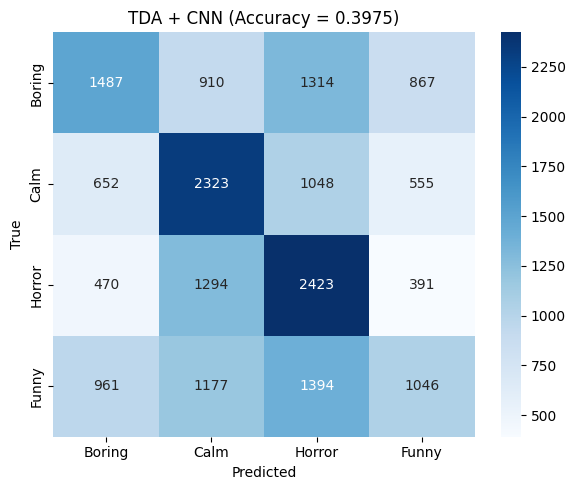


Predictions saved.


In [39]:



model.eval()

with torch.no_grad():

    test_outputs = model(

        X_test_t.to(device)

    )

    y_pred = test_outputs.argmax(1).cpu().numpy()

acc = accuracy_score(

    y_test,

    y_pred

)

print()

print(f"Test Accuracy : {acc:.4f}")

print()

print(

    classification_report(

        y_test,

        y_pred,

        target_names=EMOTION_LABELS

    )

)

plot_cm(

    y_test,

    y_pred,

    f"TDA + CNN (Accuracy = {acc:.4f})"

)

pd.DataFrame(

    {

        "True": y_test,

        "Predicted": y_pred

    }

).to_csv(

    "tda_results.csv",

    index=False

)

print()

print("Predictions saved.")